# KNN Classification on the Diabetes Dataset

This notebook uses K-Nearest Neighbors (KNN) to predict whether a patient has diabetes based on medical measurements. Unlike the Iris dataset which was very clean, this dataset has real-world issues like missing values and imbalanced classes.

The Pima Indians Diabetes dataset comes from the National Institute of Diabetes and Digestive and Kidney Diseases. It has 768 patient records with 8 medical features and a binary outcome: diabetic (1) or not diabetic (0).

Source: UCI Machine Learning Repository / Kaggle

## Step 1: Import Libraries

In [1]:
# Import the libraries we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import tools from sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

## Step 2: Load the Diabetes Dataset

We load the dataset from a CSV file. Each row represents one patient with 8 medical measurements and an outcome column that tells us if the patient was diagnosed with diabetes.

In [2]:
# Load the diabetes dataset from our CSV file
df = pd.read_csv('diabetes.csv')

# Show the first 10 rows
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [3]:
# Check the size of the dataset
print("Number of patients:", df.shape[0])
print("Number of columns:", df.shape[1])
print()
print("Column names:")
for col in df.columns:
    print(" -", col)

Number of patients: 768
Number of columns: 9

Column names:
 - Pregnancies
 - Glucose
 - BloodPressure
 - SkinThickness
 - Insulin
 - BMI
 - DiabetesPedigreeFunction
 - Age
 - Outcome


### What Each Column Means

- **Pregnancies**: Number of times the patient has been pregnant
- **Glucose**: Blood sugar level after a glucose tolerance test
- **BloodPressure**: Diastolic blood pressure (mm Hg)
- **SkinThickness**: Triceps skin fold thickness (mm)
- **Insulin**: 2-hour serum insulin level
- **BMI**: Body mass index (weight in kg / height in m squared)
- **DiabetesPedigreeFunction**: A score that represents diabetes history in the family
- **Age**: Age in years
- **Outcome**: 1 = has diabetes, 0 = does not have diabetes

## Step 3: Explore the Data

In [4]:
# Look at basic statistics
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [6]:
# Check the class distribution
print("Outcome distribution:")
print(df['Outcome'].value_counts())
print()
total = len(df)
diabetic = (df['Outcome'] == 1).sum()
not_diabetic = (df['Outcome'] == 0).sum()
print("Not diabetic: {} ({:.1f}%)".format(not_diabetic, not_diabetic/total*100))
print("Diabetic:     {} ({:.1f}%)".format(diabetic, diabetic/total*100))

Outcome distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Not diabetic: 500 (65.1%)
Diabetic:     268 (34.9%)


The dataset is imbalanced. About 65% of patients are not diabetic and 35% are diabetic. This is important to keep in mind because a model that always predicts "not diabetic" would still get 65% accuracy without learning anything useful. That is why we look at precision, recall, and F1 in addition to accuracy.

## Step 4: Handle Invalid Zero Values

There is a problem with this dataset. Some columns have values of 0 where 0 is not medically possible. For example, a person cannot have a Glucose level of 0 or a BMI of 0. These zeros are actually missing values that were recorded as 0.

We will replace these invalid zeros with the median value of each column. The median is a good choice because it is not affected by extreme values (outliers).

In [7]:
# These columns cannot have a value of 0 in real life
columns_with_invalid_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Count how many zeros are in each column before fixing
print("Invalid zeros before cleaning:")
for col in columns_with_invalid_zeros:
    zero_count = (df[col] == 0).sum()
    print("  {}: {} zeros".format(col, zero_count))

Invalid zeros before cleaning:
  Glucose: 5 zeros
  BloodPressure: 35 zeros
  SkinThickness: 227 zeros
  Insulin: 374 zeros
  BMI: 11 zeros


In [8]:
# Replace zeros with NaN first, then fill with the median
for col in columns_with_invalid_zeros:
    # Replace 0 with NaN (Not a Number = missing)
    df[col] = df[col].replace(0, np.nan)
    
    # Fill NaN with the median of that column
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)
    
    print("Replaced zeros in {} with median: {:.1f}".format(col, median_value))

print()
print("Cleaning done. No more invalid zeros.")

Replaced zeros in Glucose with median: 117.0
Replaced zeros in BloodPressure with median: 72.0
Replaced zeros in SkinThickness with median: 29.0
Replaced zeros in Insulin with median: 125.0
Replaced zeros in BMI with median: 32.3

Cleaning done. No more invalid zeros.


In [9]:
# Verify: check that there are no more zeros in those columns
print("Zeros after cleaning:")
for col in columns_with_invalid_zeros:
    zero_count = (df[col] == 0).sum()
    print("  {}: {} zeros".format(col, zero_count))

Zeros after cleaning:
  Glucose: 0 zeros
  BloodPressure: 0 zeros
  SkinThickness: 0 zeros
  Insulin: 0 zeros
  BMI: 0 zeros


## Step 5: Prepare the Data

Now we separate features from the target, split into train/test, and scale the features.

In [10]:
# Separate features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (768, 8)
Target shape: (768,)


In [11]:
# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape[0], "samples")
print("Testing set:", X_test.shape[0], "samples")

Training set: 614 samples
Testing set: 154 samples


In [ ]:
# Scale the features
# Why? Scaling is important for KNN because it ensures that all features contribute equally to the distance calculation.
# Without scaling, features with larger scales (e.g., Glucose) would disproportionately influence the distance metric, causing the model to be biased towards those features.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Fit on training data, transform both training and test data
X_test_scaled = scaler.transform(X_test)

print("Scaling done.")

Scaling done.


## Step 6: Test KNN with Different K Values

Just like we did with Iris, we will test multiple K values to find the one that gives the best accuracy. Because this dataset is harder than Iris (more features, noisy data, overlapping classes), we expect lower accuracy and more variation across K values.

In [ ]:
# Test different K values
k_values = [1, 3, 5, 7, 9, 11, 15, 20, 31, 51]
accuracies = []

for k in k_values:
    # Create and train a KNN model
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train) # Fit on training data
    
    # Make predictions and calculate accuracy
    predictions = knn.predict(X_test_scaled) # Predict on test data
    accuracy = accuracy_score(y_test, predictions) # Calculate accuracy
    accuracies.append(accuracy)
    
    print("K = {:2d}  |  Accuracy = {:.4f}".format(k, accuracy))

K =  1  |  Accuracy = 0.6558
K =  3  |  Accuracy = 0.7208
K =  5  |  Accuracy = 0.7208
K =  7  |  Accuracy = 0.7078
K =  9  |  Accuracy = 0.7403
K = 11  |  Accuracy = 0.7662
K = 15  |  Accuracy = 0.7532
K = 20  |  Accuracy = 0.7597
K = 31  |  Accuracy = 0.7532
K = 51  |  Accuracy = 0.7662


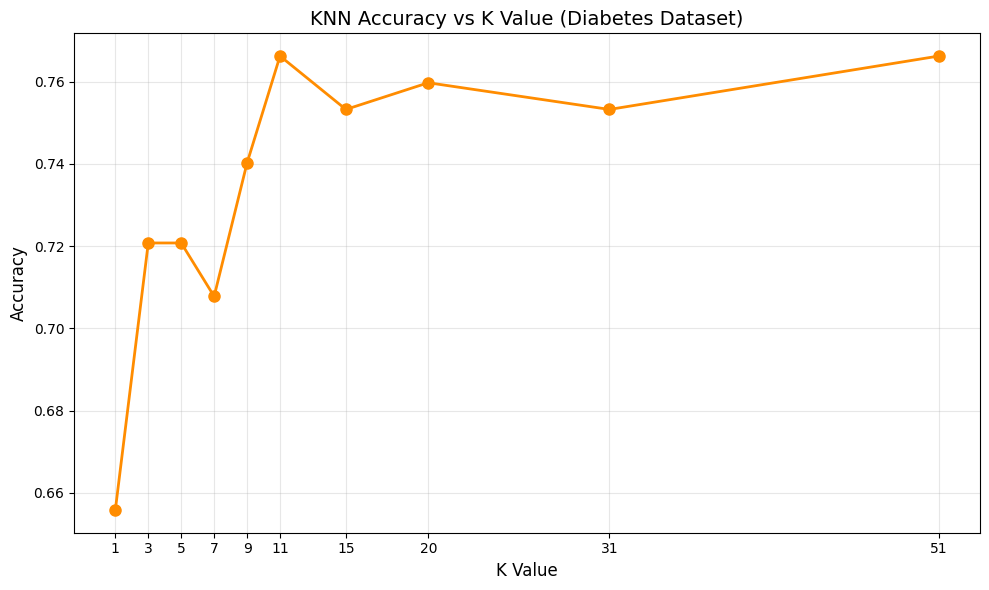

In [14]:
# Plot accuracy vs K value
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linewidth=2, markersize=8, color='darkorange')
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('KNN Accuracy vs K Value (Diabetes Dataset)', fontsize=14)
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Find the best K value
best_index = accuracies.index(max(accuracies))
best_k = k_values[best_index]
best_accuracy = max(accuracies)

print("Best K value:", best_k)
print("Best accuracy: {:.4f}".format(best_accuracy))

Best K value: 11
Best accuracy: 0.7662


## Step 7: Bias-Variance Tradeoff on Diabetes Data

Compared to the Iris dataset, the Diabetes K-value plot should show more variation. This is because the Diabetes data is harder:
- It has 8 features instead of 4
- The classes (diabetic vs not) overlap much more
- There is noise in the measurements
- The dataset is imbalanced

**Low K values** tend to overfit because KNN latches onto individual noisy data points. **High K values** tend to underfit because the model looks at too many neighbors and the prediction gets washed out. The sweet spot is the K value where accuracy is highest on the test set.

Notice that even the best accuracy on Diabetes is lower than what we got on Iris. That is normal and expected for a harder dataset.

## Step 8: Final Model Evaluation

In [16]:
# Train the final KNN model with the best K
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

# Make predictions
final_predictions = final_knn.predict(X_test_scaled)

# Calculate all metrics
accuracy = accuracy_score(y_test, final_predictions)
precision = precision_score(y_test, final_predictions)
recall = recall_score(y_test, final_predictions)
f1 = f1_score(y_test, final_predictions)

print("=== Final KNN Model Results (K = {}) ===".format(best_k))
print()
print("Accuracy:  {:.4f}".format(accuracy))
print("Precision: {:.4f}".format(precision))
print("Recall:    {:.4f}".format(recall))
print("F1 Score:  {:.4f}".format(f1))

=== Final KNN Model Results (K = 11) ===

Accuracy:  0.7662
Precision: 0.6863
Recall:    0.6364
F1 Score:  0.6604


For a binary classification problem like this, the metrics mean:
- **Accuracy**: Overall percentage of correct predictions
- **Precision**: Of the patients the model predicted as diabetic, how many actually were? High precision means fewer false alarms.
- **Recall**: Of all the patients who actually have diabetes, how many did the model catch? High recall means fewer missed cases.
- **F1 Score**: The balance between precision and recall

In a medical context, recall is especially important. Missing a diabetic patient (low recall) could mean they do not get the treatment they need.

### Confusion Matrix

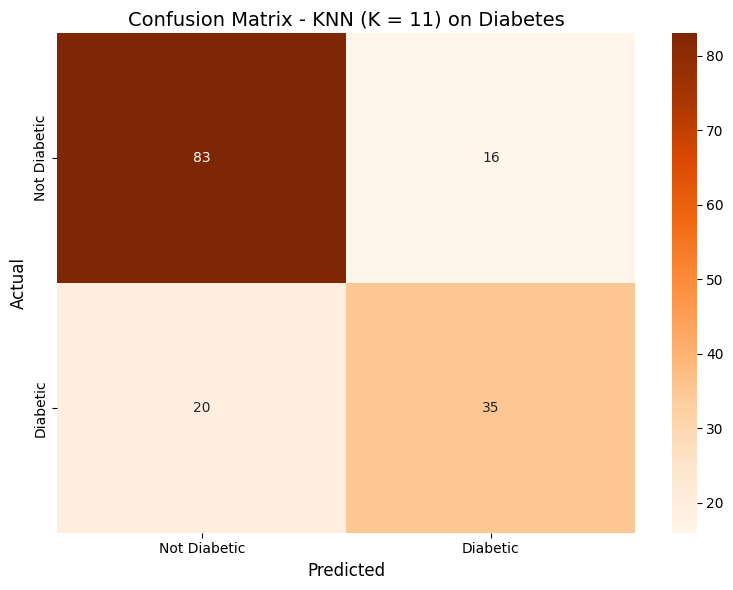

In [17]:
# Create and plot the confusion matrix
cm = confusion_matrix(y_test, final_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Not Diabetic', 'Diabetic'],
    yticklabels=['Not Diabetic', 'Diabetic']
)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - KNN (K = {}) on Diabetes'.format(best_k), fontsize=14)
plt.tight_layout()
plt.show()

In the confusion matrix:
- **Top-left**: patients correctly predicted as not diabetic (true negatives)
- **Top-right**: patients incorrectly predicted as diabetic (false positives)
- **Bottom-left**: diabetic patients the model missed (false negatives) — this is the dangerous one
- **Bottom-right**: patients correctly predicted as diabetic (true positives)

### Classification Report

In [18]:
# Print the full classification report
print("Classification Report:")
print()
print(classification_report(y_test, final_predictions, 
                            target_names=['Not Diabetic', 'Diabetic']))

Classification Report:

              precision    recall  f1-score   support

Not Diabetic       0.81      0.84      0.82        99
    Diabetic       0.69      0.64      0.66        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.76       154



## Summary

In this notebook we used KNN on the Diabetes dataset. Here is what we did and learned:

1. Loaded the Pima Indians Diabetes dataset (768 patients, 8 features)
2. Found that the dataset had invalid zero values in medical columns and replaced them with medians
3. The dataset is imbalanced (65% not diabetic, 35% diabetic)
4. Tested K values from 1 to 51 and found the optimal K
5. The accuracy on Diabetes is lower than on Iris because the data is harder and the classes overlap
6. In a medical setting, recall matters most because missing a diabetic patient has real consequences

This result will be compared with SVM on the same Diabetes dataset in the next notebook.